# Plot color maps for subbandgap-reflectors

Created on 2026-04-20

This notebook recreates the two subfigures of Fig. 4 in the Manuscript [1].

[1] K. Jäger, J. Mandal, B. P. Rand, F. Meggers, and C. Becker. "How do sub-bandgap reflectors affect the performance of photovoltaic modules?" arXiv 2604.20757 (2026)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from pv_tandem.thermal import GetLocData, CalcEY

## Initialize EY class

In [2]:
# Initialize PV module dictionary
pv_dict = {
    # Geometrical parameters
    'module_height': 1.5,               # in m
    'module_width': 1.1,                # in m
    'module_length': 1.7,               # in m
    'module_spacing': 100,              # in m
    'module_tilt_deg': 34.5,            # optimal tilt for TMY 2024 data in Princeton
    'module_plane_azimuth_deg': 180,    # PV module is facing South
    'ground_steps': 101,                # steps in view factor model

    # Environmental parameter
    'albedo': 0.3,

    # Parameters for temperature models (Ross, Fuentes or SAPM, from pvlib)
    'fuentes_module_emissivity': 0.84,  # Default: 0.84, used in Fuentes model
    'noct': 45,                         # Used in Ross model     
    'sapm_module_mount': 0,             # Used in SAPM model
                                        # 0: glass/glass, open rack
                                        # 1: glass/glass, close roof
                                        # 2: glass/polymer, open rack
                                        # 3: glass/polymer, insulated back

    # Parameters for electrical one-diode model
    'j_sc_STC': 39,                     # Short circuit current density at STC
    'PCE': 24.76,                       # Power conversion efficiency of PV module at STC in %
    'tc_P': -0.40,                      # Temperature coefficient for power in %/K
    'tc_j_sc': 0.03,                    # Temperature coefficient for short-circuit current density in %/K
    'tc_V_oc': -0.4,                    # Temperature coefficient for open-circuit voltage in %/K
    'R_shunt': 3000,                    # Shunt resistance
    'R_series': 1.5,                    # Series resistance
    'n': 1,                             # Diode ideality factor
    'j_0': 1e-12,                       # Dark current density

    # Thermal coating parameter
    'loss': 0,                          # Loss of thermal coating

    # Filepath to csv file containing PV module reflectance
    'reflection_filepath': '../data_thermal/SEMSC_Subedi_ea_PERC_UVVisNIR_sim_2020_Fig5b.csv'
    }

# General configuration variables
config_dict = {'irrad_model': 'vf',     # Irradiation model. "vf" or "simple"
               'temp_model': 'SAPM',    # Temperature model "Ross", "Fuentes", or "SAPM"
               'spectral': True         # Set, whether NSRDB data is spectral or not
              }

In [3]:
# Load NSRDB data and populate the "loc_data" dictionary
nsrdb_data_filepath = '../data_thermal/princeton-2024-1223393-fixed_tilt_35_spectral.csv'
loc_data = GetLocData(nsrdb_data_filepath = nsrdb_data_filepath,
                      pv_reflection_filepath = pv_dict['reflection_filepath'],
                      spectral_boolean =config_dict['spectral']
                      ) 
# Initialize Class "CalcEY"
ey_test = CalcEY(loc_data = loc_data.data,
                 pv_dict = pv_dict,
                 config_dict = config_dict)

## Make Figures
### Color plot for dependence on loss and temperature coefficient

In [4]:
# Define some arrays
tc_array = -np.linspace(0,0.5,26) # temperature coefficient
loss_array = np.linspace(0,.05,11)
gain_array = np.zeros([len(tc_array),len(loss_array)])

In [5]:
# Calculate results for a glass-glass module in open-rack mount
pv_dict['sapm_module_mount'] = 0
for i,loss in enumerate(loss_array):
    for j, tc in enumerate(tc_array):  
        pv_dict['tc_P'] = tc
        pv_dict['loss'] = loss
        ey_test.get_ey_tc()
        ey_ref = ey_test.res['ey_tc_ref']
        ey_sbr = ey_test.res['ey_tc_sbr']
        gain_array[j,i] = (ey_sbr-ey_ref)/ey_ref

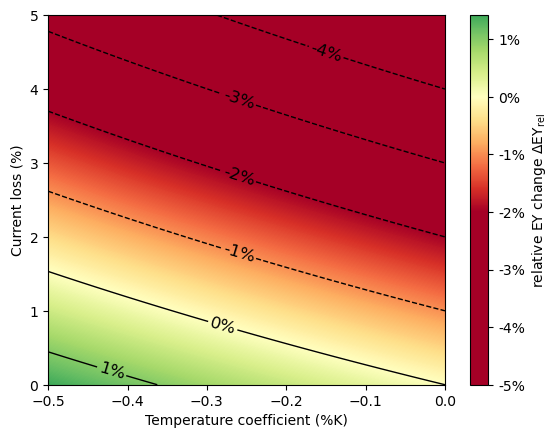

In [6]:
# Plot the figure
plt.figure()
plt.contourf(tc_array,loss_array*100,gain_array.T*100,levels = 1000,cmap = cm.RdYlGn,vmin = -2, vmax = 2)
plt.colorbar(ticks = np.linspace(-5,2,8),format = '%d%%',label = "relative EY change $\Delta$EY$_\mathsf{rel}$")
c_set_w = plt.contour(tc_array,loss_array*100,gain_array.T*100,colors = 'k', linewidths = 1, levels = np.linspace(-5,2,8))
plt.clabel(c_set_w,fmt = '%d%%',inline_spacing=2,fontsize = 12)
plt.ylabel('Current loss (%)')
plt.xlabel('Temperature coefficient (%K)')
plt.show()

In [7]:
# Calculate results for a glass-glass module in close-roof mount
pv_dict['sapm_module_mount'] = 1
for i,loss in enumerate(loss_array):
    for j, tc in enumerate(tc_array):  
        pv_dict['tc_P'] = tc
        pv_dict['loss'] = loss
        ey_test.get_ey_tc()
        ey_ref = ey_test.res['ey_tc_ref']
        ey_sbr = ey_test.res['ey_tc_sbr']
        gain_array[j,i] = (ey_sbr-ey_ref)/ey_ref

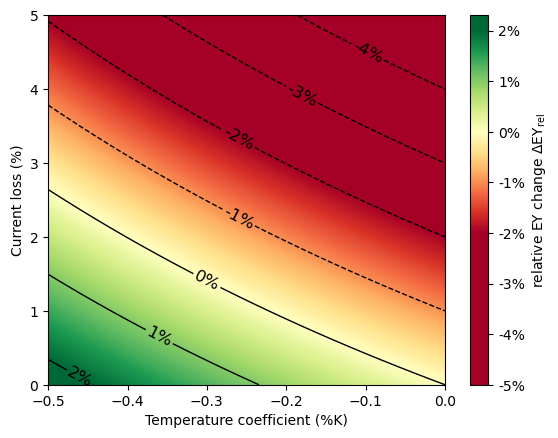

In [8]:
# Plot the figure
plt.figure()
plt.contourf(tc_array,loss_array*100,gain_array.T*100,levels = 1000,cmap = cm.RdYlGn,vmin = -2, vmax = 2)
plt.colorbar(ticks = np.linspace(-5,2,8),format = '%d%%',label = "relative EY change $\Delta$EY$_\mathsf{rel}$")
#plt.contour(loss_array,tc_array,gain_array,colors = 'white', linewidths = 1, levels = np.linspace(-5,1,7)/100)
c_set_w = plt.contour(tc_array,loss_array*100,gain_array.T*100,colors = 'k', linewidths = 1, levels = np.linspace(-5,2,8))
plt.clabel(c_set_w,fmt = '%d%%',inline_spacing=2,fontsize = 12)
plt.ylabel('Current loss (%)')
plt.xlabel('Temperature coefficient (%K)')
plt.show()